In [1]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report

In [2]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

import tqdm


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Dataset

In [4]:
directory = "C:\\Users\\User\\Documents\\ДЗ\\NA_Fish_Dataset"

In [5]:
labels = os.listdir(directory)

In [6]:
labels

['Black Sea Sprat',
 'Gilt Head Bream',
 'Horse Mackerel',
 'Red Mullet',
 'Red Sea Bream',
 'Sea Bass',
 'Shrimp',
 'Striped Red Mullet',
 'Trout']

In [7]:
image_paths = []
target = []
for fish_type in labels:
    for file in os.listdir(os.path.join(directory, fish_type)):
        image_paths.append(os.path.join(directory, fish_type, file))
        target.append(fish_type)

In [8]:
df = pd.DataFrame({'img' : image_paths, 'target' : target})
df.head()

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat


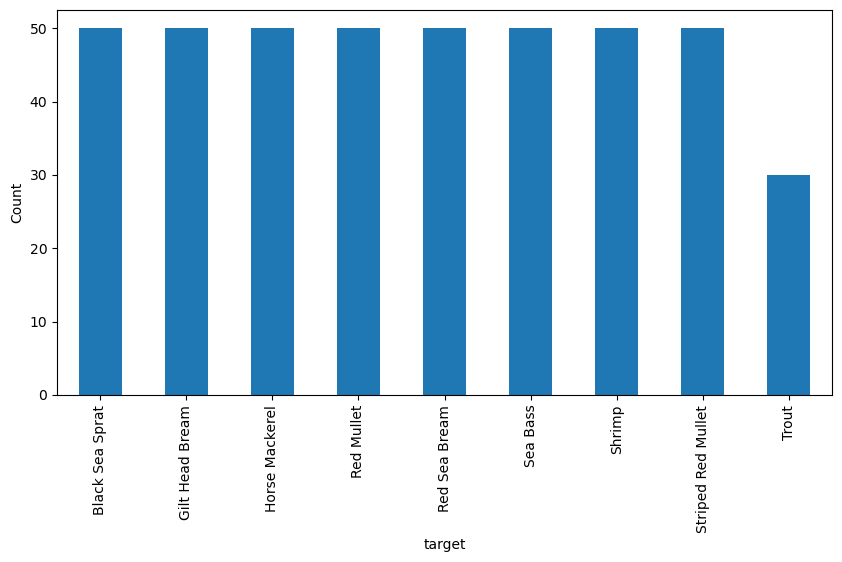

In [9]:
plt.figure(figsize=(10, 5))
df['target'].value_counts().plot(kind='bar')
plt.ylabel('Count')
plt.show()

In [10]:
indices_to_drop = df[~df['target'].isin(['Black Sea Sprat', 'Gilt Head Bream'])].index
df2 = df.drop(indices_to_drop)

In [11]:
df2

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
...,...,...
95,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
96,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
97,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
98,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream


In [12]:
pip install timm torch torchvision pillow scikit-learn seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
train_df, test_df = train_test_split(
    df2,
    test_size=0.2,
    random_state=42,
    stratify=df2['target']
)

In [14]:
classes_list = sorted(df2['target'].unique()) ## список уникальных названий видов рыб
class_to_idx = {name: i for i, name in enumerate(classes_list)} ##словарь название вида рыбы → числовой индекс 
num_classes = len(classes_list)

train_df['label_idx'] = train_df['target'].apply(lambda x: class_to_idx[x]) ##числовые метки
test_df['label_idx'] = test_df['target'].apply(lambda x: class_to_idx[x])

In [15]:
train_df

,img,target,label_idx
15,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
52,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
60,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
66,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
68,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
...,...,...,...
17,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
36,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
85,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
21,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0


In [16]:
IMG_SIZE = 64  
BATCH_SIZE = 32

train_transform = transforms.Compose([ 
    transforms.Resize((IMG_SIZE, IMG_SIZE)),##приводим все картинки к 64×64 
    transforms.RandomHorizontalFlip(),##аугментация
    transforms.ToTensor(),  # нормализует в [0,1] и делает CHW
])

'''val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])'''
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [60]:
class ImageDataFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)  # чтобы индексы шли подряд
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['img']
        label = row['label_idx']

        # Загрузка картинки
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = ImageDataFrameDataset(train_df, transform=train_transform)
test_dataset  = ImageDataFrameDataset(test_df,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
##val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [19]:
num_classes = len(classes_list)  # число классов
input_dim = IMG_SIZE * IMG_SIZE * 3        # размер «сплющенного» вектора

In [20]:
class MLPImageClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=[512, 256]):
        super().__init__()
        layers = [] ##пустой список, куда будем складывать слои
        prev_dim = input_dim ##размерность предыдущего слоя

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h)) ##полносвязный слой-умножает вектор на матрицу весов
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU()) ##функция активации
            layers.append(nn.Dropout(0.3)) ##случайно «выключает» 30 % нейронов — защита от переобучения
            prev_dim = h ##Обновляем prev_dim, чтобы следующий слой знал размер входа.

        layers.append(nn.Linear(prev_dim, num_classes))  # выходной слой без активации
        self.network = nn.Sequential(*layers)## склеивает все слои в единую цепочку.

    def forward(self, x):
        # x: [B, C, H, W]
        x = x.view(x.size(0), -1)  # <-- сплющивание: превращает картинку [batch, channels, height, width] в вектор [batch, channels*height*width]
        return self.network(x)

In [21]:
model = MLPImageClassifier(input_dim, num_classes, hidden_dims=[512, 256])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

MLPImageClassifier(
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=2, bias=True)
  )
)

In [22]:
criterion = nn.CrossEntropyLoss() ##функция потерь
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)## АДам - оптимизатор для обучения нейросетей
##комбинирует идеи двух методов Momentum — накапливает «инерцию» прошлых градиентов, чтобы ускоряться в стабильных направлениях и сглаживать шум.
##RMSProp — адаптирует шаг обучения под масштаб градиентов: для параметров с большими градиентами шаг уменьшается, для маленьких — увеличивается.

In [23]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
epochs = 10

In [26]:
for epoch in range(epochs):
    # Train
    model.train()
    train_loss_sum = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad() ##обнуляем градиенты перед новым шагом

        outputs = model(imgs) ##Прогон через модель: получаем сырые выходы
        loss = criterion(outputs, labels)
        loss.backward() ##градиенты
        optimizer.step()##обновляем веса сети

        train_loss_sum += loss.item() * imgs.size(0) ##Накапливаем суммарный loss 
        preds = outputs.argmax(dim=1) ## выбираем класс с наибольшей вероятностью
        correct_train += (preds == labels).sum().item()##Считаем, сколько предсказаний совпало с истиной
        total_train += labels.size(0) ##Суммируем общее число примеров

    avg_train_loss = train_loss_sum / total_train ##Усредняем loss и accuracy по всему train‑набору
    train_acc = correct_train / total_train

    history['train_loss'].append(avg_train_loss)
##    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
##    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, "
          f"train_acc={train_acc:.4f}")




Epoch 1: train_loss=0.6143, train_acc=0.6125
Epoch 2: train_loss=0.3292, train_acc=0.8375
Epoch 3: train_loss=0.1841, train_acc=0.9750
Epoch 4: train_loss=0.1387, train_acc=0.9750
Epoch 5: train_loss=0.0836, train_acc=1.0000
Epoch 6: train_loss=0.1098, train_acc=0.9875
Epoch 7: train_loss=0.0648, train_acc=0.9875
Epoch 8: train_loss=0.0481, train_acc=0.9875
Epoch 9: train_loss=0.0449, train_acc=0.9875
Epoch 10: train_loss=0.0730, train_acc=0.9875


In [27]:
##print("val_acc values:", history['val_acc'])

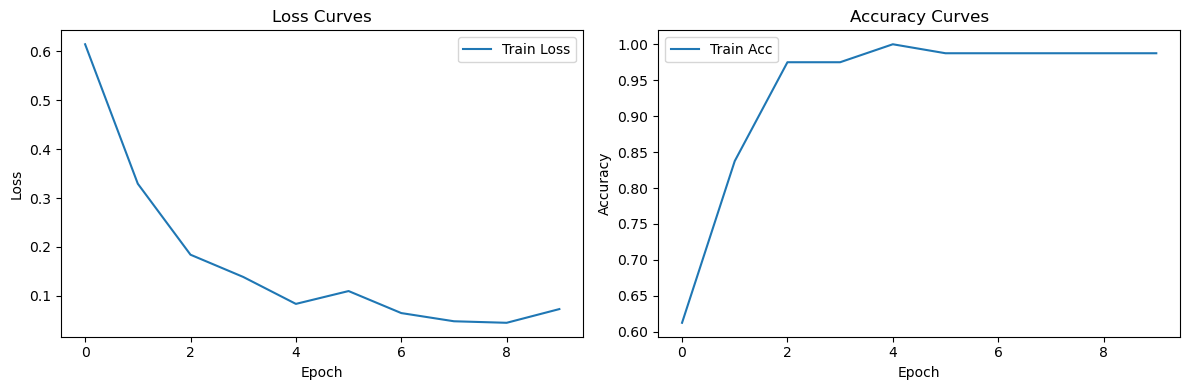

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
##plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
##plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')
plt.tight_layout()
plt.show()

In [29]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

In [30]:
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Test Accuracy: {acc:.4f}, Test F1: {f1:.4f}")
print(classification_report(y_true, y_pred))##даёт precision, recall, F1 по каждому классу

Test Accuracy: 1.0000, Test F1: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



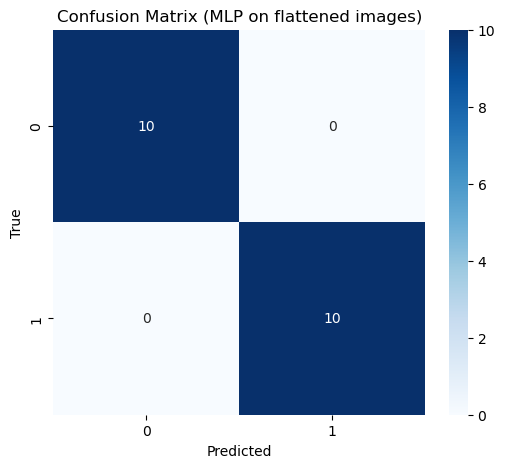

In [31]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (MLP on flattened images)')
plt.show()

In [32]:
from tensorflow import keras
from tensorflow.keras import layers

In [33]:
##Уровень 2 -используем модель ResNet18

In [34]:
train_df_full, test_df_full = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

In [35]:
classes_list_full = sorted(df['target'].unique()) ## список уникальных названий видов рыб
class_to_idx = {name: i for i, name in enumerate(classes_list_full)} ##словарь название вида рыбы → числовой индекс 
num_classes = len(classes_list_full)

train_df['label_idx'] = train_df_full['target'].apply(lambda x: class_to_idx[x]) ##числовые метки
test_df['label_idx'] = test_df_full['target'].apply(lambda x: class_to_idx[x])

In [36]:
class FishDatasetFromDF(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        unique_labels = sorted(df['target'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['img']
        label_name = row['target']
        
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        
        label = self.label_to_idx[label_name]
        return img, label

In [37]:
from torch.utils.data import Dataset, DataLoader
train_transform = v2.Compose([
    v2.Resize((224, 224)), ##приводит все картинки к размеру 224×224 пикселя
    v2.ToTensor(), 
##   v2.ToImage(),## гарантирует, что объект внутри пайплайна имеет правильный тип изображения  
##   v2.ToDtype(torch.float32, scale=True),##  конвертирует картинку в float32 и масштабирует значения пикселей из диапазона [0, 255] в [0.0, 1.0]. Без этого нормализация дальше не сработает корректно
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = v2.Compose([
    v2.Resize((224, 224)),##нужен, чтобы размер совпадал с тем, что ожидает модель
##    v2.ToImage(),##приводит формат и масштаб пикселей к нужному виду.
##    v2.ToDtype(torch.float32, scale=True),
    v2.ToTensor(), 
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

C:\Users\User\anaconda3\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.6

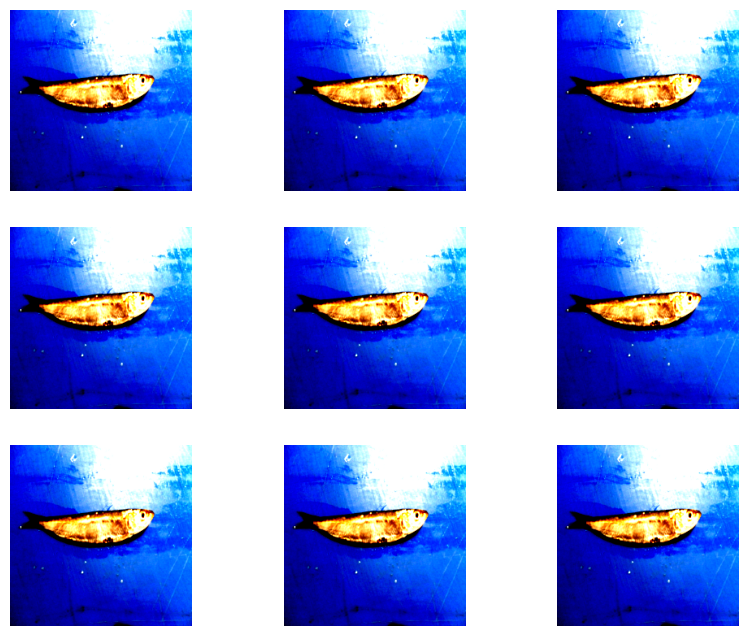

In [38]:
image = Image.open(df['img'].iloc[0])

sample_size = 9
fig, ax = plt.subplots(3, 3, figsize=(10, 8))
ax = ax.flatten()

for i in range(sample_size):
    augmented = train_transform(image)
    ax[i].imshow(augmented.permute(1, 2, 0))
    ax[i].axis('off')

plt.axis('off')
plt.show()

In [39]:

train_dataset = FishDatasetFromDF(train_df_full, transform=train_transform)
test_dataset  = FishDatasetFromDF(test_df_full,  transform=test_transform)

classes = train_dataset.idx_to_label
print("Классы:", classes)
print("Train size:", len(train_dataset))
print("Test size:",  len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)##берёт объекты Dataset и отдаёт данные батчами (по 32 картинки)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

Классы: {0: 'Black Sea Sprat', 1: 'Gilt Head Bream', 2: 'Horse Mackerel', 3: 'Red Mullet', 4: 'Red Sea Bream', 5: 'Sea Bass', 6: 'Shrimp', 7: 'Striped Red Mullet', 8: 'Trout'}
Train size: 344
Test size: 86


In [40]:
import timm

img_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") ##устройство для вычислений: CUDA-GPU ,

backbone_name = "resnet18" 
backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
feature_dim = backbone.num_features


mlp = nn.Sequential( ##классификатор (многослойный перцептрон) как последовательность слоёв
    nn.Linear(feature_dim, 256),##линейный слой: вход — размерность признаков, выход — 256 нейронов.
    nn.BatchNorm1d(256),## — пакетная нормализация по батчу для 256 признаков
    nn.ReLU(),##функция активации ReLU (--//)
    nn.Dropout(0.3),
    nn.Linear(256, len(classes)),##финальный линейный слой: выход равен числу классов
)

class TimmMLP(nn.Module):
    def __init__(self, backbone, mlp):
        super().__init__()
        self.backbone = backbone
        self.mlp = mlp

    def forward(self, x): ##Вход изображения подаётся на backbone, получаем признаки features.Признаки подаются на MLP, который возвращает финальные логиты по классам
        features = self.backbone(x)
        return self.mlp(features)
        
model = timm.create_model("resnet18", pretrained=True, num_classes=num_classes)

criterion = nn.CrossEntropyLoss()## Функция потерь для многоклассовой классификации
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [41]:
num_epochs = 10 ##Количество эпох

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0 ##Сброс счётчиков для текущей эпохи
    correct = 0
    total = 0

    for imgs, labels in train_loader: ##Перебор батчей (мини‑наборов) из DataLoader
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad() ##Обнуление градиентов. Иначе градиенты будут накапливаться от предыдущих батчей.
        outputs = model(imgs)
        loss = criterion(outputs, labels)## Вычисление функции потерь
        loss.backward()##Обратное распространение ошибки: вычисляются градиенты по весам модели.
        optimizer.step()##Обновление весов модели на основе посчитанных градиентов

        running_loss += loss.item() * imgs.size(0) ##Накопление потерь
        preds = outputs.argmax(dim=1)## предсказанные классы: для каждой картинки выбираем индекс с максимальным значением
        correct += (preds == labels).sum().item() ##число правильных предсказаний в батче и общее количество примеров
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

Epoch 1/10 | Loss: 1.9570 | Acc: 0.4041
Epoch 2/10 | Loss: 1.1241 | Acc: 0.8808
Epoch 3/10 | Loss: 0.4395 | Acc: 0.9826
Epoch 4/10 | Loss: 0.1009 | Acc: 1.0000
Epoch 5/10 | Loss: 0.0343 | Acc: 1.0000
Epoch 6/10 | Loss: 0.0264 | Acc: 0.9942
Epoch 7/10 | Loss: 0.0147 | Acc: 0.9971
Epoch 8/10 | Loss: 0.0094 | Acc: 1.0000
Epoch 9/10 | Loss: 0.0059 | Acc: 1.0000
Epoch 10/10 | Loss: 0.0049 | Acc: 1.0000



Accuracy: 1.0000, F1 weighted: 1.0000
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00        10
   Gilt Head Bream       1.00      1.00      1.00        10
    Horse Mackerel       1.00      1.00      1.00        10
        Red Mullet       1.00      1.00      1.00        10
     Red Sea Bream       1.00      1.00      1.00        10
          Sea Bass       1.00      1.00      1.00        10
            Shrimp       1.00      1.00      1.00        10
Striped Red Mullet       1.00      1.00      1.00        10
             Trout       1.00      1.00      1.00         6

          accuracy                           1.00        86
         macro avg       1.00      1.00      1.00        86
      weighted avg       1.00      1.00      1.00        86



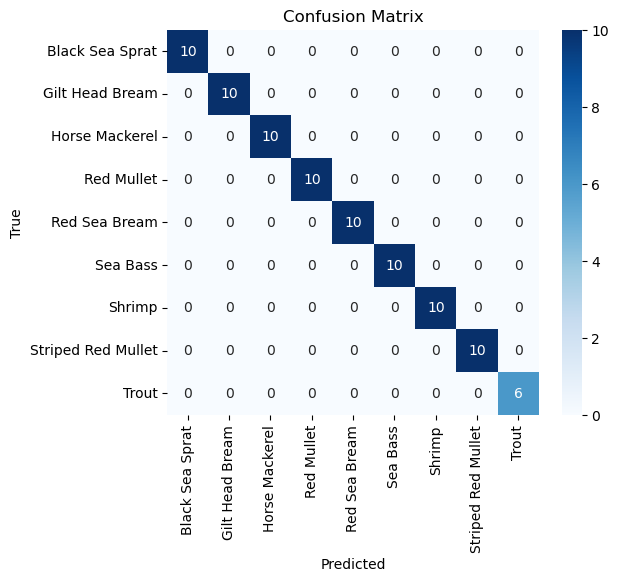

In [42]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
print(f"\nAccuracy: {acc:.4f}, F1 weighted: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=[classes[i] for i in range(len(classes))]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[classes[i] for i in range(len(classes))],
            yticklabels=[classes[i] for i in range(len(classes))])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [43]:
## 3 c аугментацией

In [44]:
from torch.utils.data import Dataset, DataLoader
train_transform3 = v2.Compose([
    v2.Resize((224, 224)), ##приводит все картинки к размеру 224×224 пикселя
    v2.RandomHorizontalFlip(p=0.5),## вероятностью 50% отражает картинку по горизонтали: неважно, плывёт рыба влево или вправо — класс тот же
    v2.RandomRotation(degrees=15),##поворачивает картинку на случайный угол в диапазоне ±15°
    v2.ColorJitter(
        brightness=0.2, ## немного меняет яркость и контраст. Ещё один способ аугментации, чтобы сеть не зависела от условий съёмки.  
        contrast=0.2,  
        saturation=0.15,  
        hue=0.05        
    ),
    v2.ToTensor(), 
##   v2.ToImage(),## гарантирует, что объект внутри пайплайна имеет правильный тип изображения  
##   v2.ToDtype(torch.float32, scale=True),##  конвертирует картинку в float32 и масштабирует значения пикселей из диапазона [0, 255] в [0.0, 1.0]. Без этого нормализация дальше не сработает корректно
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform3 = v2.Compose([
    v2.Resize((224, 224)),##нужен, чтобы размер совпадал с тем, что ожидает модель
##    v2.ToImage(),##приводит формат и масштаб пикселей к нужному виду.
##    v2.ToDtype(torch.float32, scale=True),
    v2.ToTensor(), 
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

C:\Users\User\anaconda3\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.2042704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739

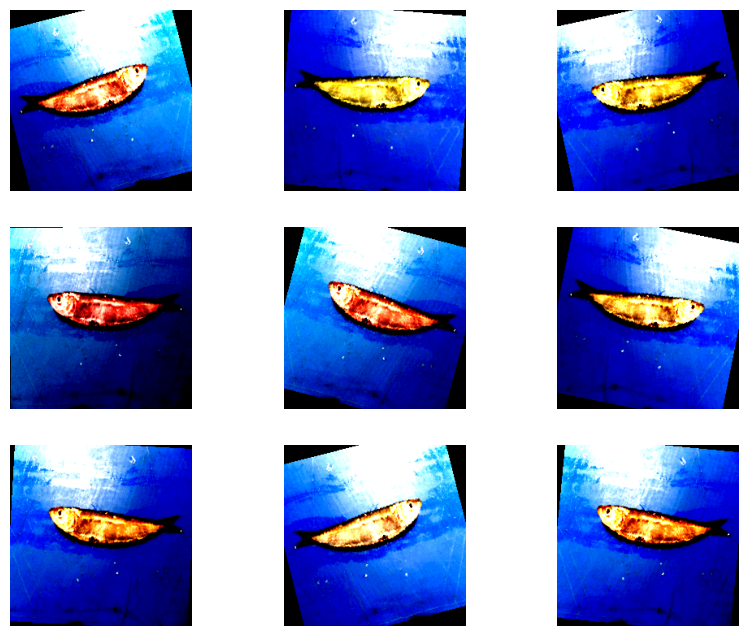

In [45]:


sample_size = 9
fig, ax = plt.subplots(3, 3, figsize=(10, 8))
ax = ax.flatten()
for i in range(sample_size):
    augmented = train_transform3(image)
    ax[i].imshow(augmented.permute(1, 2, 0))
    ax[i].axis('off')

plt.axis('off')
plt.show()

In [46]:
train_dataset3 = FishDatasetFromDF(train_df_full, transform=train_transform3)
test_dataset3  = FishDatasetFromDF(test_df_full,  transform=test_transform3)

classes = train_dataset.idx_to_label
print("Классы:", classes)
print("Train size:", len(train_dataset3))
print("Test size:",  len(test_dataset3))

train_loader3 = DataLoader(train_dataset3, batch_size=32, shuffle=True, num_workers=0)##берёт объекты Dataset и отдаёт данные батчами (по 32 картинки)
test_loader3  = DataLoader(test_dataset3,  batch_size=32, shuffle=False, num_workers=0)

Классы: {0: 'Black Sea Sprat', 1: 'Gilt Head Bream', 2: 'Horse Mackerel', 3: 'Red Mullet', 4: 'Red Sea Bream', 5: 'Sea Bass', 6: 'Shrimp', 7: 'Striped Red Mullet', 8: 'Trout'}
Train size: 344
Test size: 86


In [47]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0 ##Сброс счётчиков для текущей эпохи
    correct = 0
    total = 0

    for imgs, labels in train_loader3: ##Перебор батчей (мини‑наборов) из DataLoader
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad() ##Обнуление градиентов. Иначе градиенты будут накапливаться от предыдущих батчей.
        outputs = model(imgs)
        loss = criterion(outputs, labels)## Вычисление функции потерь
        loss.backward()##Обратное распространение ошибки: вычисляются градиенты по весам модели.
        optimizer.step()##Обновление весов модели на основе посчитанных градиентов

        running_loss += loss.item() * imgs.size(0) ##Накопление потерь
        preds = outputs.argmax(dim=1)## предсказанные классы: для каждой картинки выбираем индекс с максимальным значением
        correct += (preds == labels).sum().item() ##число правильных предсказаний в батче и общее количество примеров
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

Epoch 1/10 | Loss: 0.1941 | Acc: 0.9331
Epoch 2/10 | Loss: 0.1690 | Acc: 0.9593
Epoch 3/10 | Loss: 0.1069 | Acc: 0.9797
Epoch 4/10 | Loss: 0.0621 | Acc: 0.9797
Epoch 5/10 | Loss: 0.0338 | Acc: 0.9913
Epoch 6/10 | Loss: 0.0143 | Acc: 1.0000
Epoch 7/10 | Loss: 0.0166 | Acc: 0.9942
Epoch 8/10 | Loss: 0.0209 | Acc: 0.9913
Epoch 9/10 | Loss: 0.0189 | Acc: 0.9942
Epoch 10/10 | Loss: 0.0234 | Acc: 0.9971



Accuracy: 1.0000, F1 weighted: 1.0000
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00        10
   Gilt Head Bream       1.00      1.00      1.00        10
    Horse Mackerel       1.00      1.00      1.00        10
        Red Mullet       1.00      1.00      1.00        10
     Red Sea Bream       1.00      1.00      1.00        10
          Sea Bass       1.00      1.00      1.00        10
            Shrimp       1.00      1.00      1.00        10
Striped Red Mullet       1.00      1.00      1.00        10
             Trout       1.00      1.00      1.00         6

          accuracy                           1.00        86
         macro avg       1.00      1.00      1.00        86
      weighted avg       1.00      1.00      1.00        86

Classification report (по классам):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000

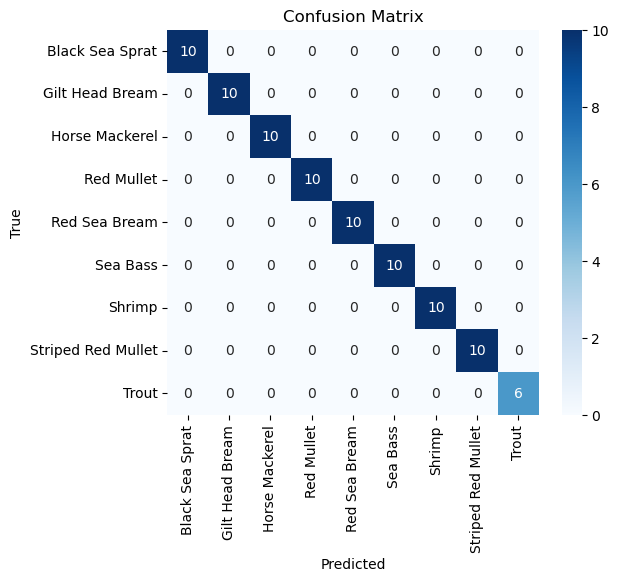

In [48]:
model.eval()
y_true3, y_pred3 = [], []

with torch.no_grad():
    for imgs, labels in test_loader3:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true3.extend(labels.numpy())
        y_pred3.extend(preds)

acc = accuracy_score(y_true3, y_pred3)
f1 = f1_score(y_true3, y_pred3, average="weighted")
print(f"\nAccuracy: {acc:.4f}, F1 weighted: {f1:.4f}")
print(classification_report(y_true3, y_pred3, target_names=[classes[i] for i in range(len(classes))]))
#№ Метрики по классам (precision, recall, F1, support)

target_names = [str(i) for i in range(num_classes)]  # если нужны имена классов — замени на список названий
print("Classification report (по классам):")
print(classification_report(y_true3, y_pred3, target_names=target_names, digits=4))
##Матрица ошибок
cm = confusion_matrix(y_true3, y_pred3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[classes[i] for i in range(len(classes))],
            yticklabels=[classes[i] for i in range(len(classes))])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [63]:
 ##первый батч тестовой выборки и какие классы модель проставила
class ImageDataFrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)  # чтобы индексы шли подряд
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['img']
        label = row['label_idx']

        # Загрузка картинки
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
##Возвращаем ровно 3 значения: image, label, img_path!!!
        return image, label,img_path

train_dataset = ImageDataFrameDataset(train_df, transform=train_transform)
test_dataset  = ImageDataFrameDataset(test_df,  transform=test_transform)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)        

In [64]:
model.eval()
with torch.no_grad():
    # Берём только первый батч
    imgs_batch, labels_batch, paths_batch = next(iter(test_loader))
    imgs_batch = imgs_batch.to(device)
    labels_batch = labels_batch.numpy()

    outputs = model(imgs_batch)
    preds_batch = outputs.argmax(dim=1).cpu().numpy()

    # Выводим построчно: путь, истинный класс, предсказанный класс
    for i in range(len(paths_batch)):
        print(f"[{i}] path: {paths_batch[i]}")
        print(f"    true_label: {labels_batch[i]}, pred_label: {preds_batch[i]} -> {'Класс предсказан верно' if labels_batch[i] == preds_batch[i] else 'ERROR'}")

[0] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gilt Head Bream\16.JPG
    true_label: 1, pred_label: 1 -> Класс предсказан верно
[1] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gilt Head Bream\34.JPG
    true_label: 1, pred_label: 1 -> Класс предсказан верно
[2] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gilt Head Bream\21.png
    true_label: 1, pred_label: 1 -> Класс предсказан верно
[3] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gilt Head Bream\10.JPG
    true_label: 1, pred_label: 1 -> Класс предсказан верно
[4] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Black Sea Sprat\00008.png
    true_label: 0, pred_label: 0 -> Класс предсказан верно
[5] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Black Sea Sprat\00015.png
    true_label: 0, pred_label: 0 -> Класс предсказан верно
[6] path: C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Black Sea Sprat\00021.png
    true_label: 0, pred_label: 0 -> Класс предсказан верно
[7] path: C:\Users\User\Documents\ДЗ\NA_Fish_D